In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv("dataset1.csv")

In [4]:
data['trend_fast'] = (data['days_to_trend'] <= 3).astype(int)

# Feature Engineering

In [5]:
data['like_view_ratio'] = data['like_view_ratio_pct'] / 100
data['comment_view_ratio'] = data['comment_view_ratio_pct'] / 100


In [6]:
data['log_views'] = np.log1p(data['views'])
data['log_likes'] = np.log1p(data['likes'])
data['log_dislikes'] = np.log1p(data['dislikes'])
data['log_comments'] = np.log1p(data['comments'])
data['log_subscribers'] = np.log1p(data['subscriber_count'])

data['like_dislike_ratio'] = data['likes'] / (data['dislikes'] + 1)
data['comment_like_ratio'] = data['comments'] / (data['likes'] + 1)

# Feature Selection

In [7]:
features = [
    # Main numerical features
    'views', 'likes', 'dislikes', 'comments',
    'subscriber_count',
    
    # Logarithmic features
    'log_views', 'log_likes', 'log_dislikes', 'log_comments',
    'log_subscribers',
    
    # Engagement ratios
    'like_view_ratio', 'comment_view_ratio',
    'like_dislike_ratio', 'comment_like_ratio',
    'engagement_score',
    
    # Video metadata
    'duration_seconds', 'tag_count',
    'title_length', 'description_length',
    'clickbait_score',
    
    # Temporal features (بدون days_to_trend)
    'year', 'month',
    
    # Boolean features
    'has_caps_title', 'has_emoji_title', 'has_question_title',
    'has_links_description',
    'comments_enabled', 'caption_available', 'made_for_kids',
    'channel_verified'
]

features = [f for f in features if f in data.columns]

x = data[features]
y = data['trend_fast']

#  Train-Test Split

In [8]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


# Model Architecture

In [9]:
model = keras.Sequential([
    layers.Dense(128, activation='relu'), 
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

# Model Compilation






# Training Callbacks

In [10]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall', 'auc']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=0.00001,
    verbose=1
)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Model Training

In [12]:
history = model.fit(
    x_train_scaled, y_train,
    epochs=90,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7258 - auc: 0.5002 - loss: 0.6084 - precision: 0.7588 - recall: 0.9381 - val_accuracy: 0.7475 - val_auc: 0.5172 - val_loss: 0.5739 - val_precision: 0.7475 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7456 - auc: 0.5188 - loss: 0.5811 - precision: 0.7470 - recall: 0.9973 - val_accuracy: 0.7475 - val_auc: 0.5197 - val_loss: 0.5720 - val_precision: 0.7475 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7470 - auc: 0.5332 - loss: 0.5724 - precision: 0.7482 - recall: 0.9978 - val_accuracy: 0.7475 - val_auc: 0.5062 - val_loss: 0.5709 - val_precision: 0.7475 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7434 - auc: 0.5211 - loss: 0.5800 - precision: 0.7433 - recall: 1.0000 - val_accuracy: 0.7475 - val_auc: 0.5029 - val_loss: 0.5722 - val_precisi

In [13]:
y_pred_prob = model.predict(x_test_scaled)
y_pred = (y_pred_prob >= 0.5).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 497us/step


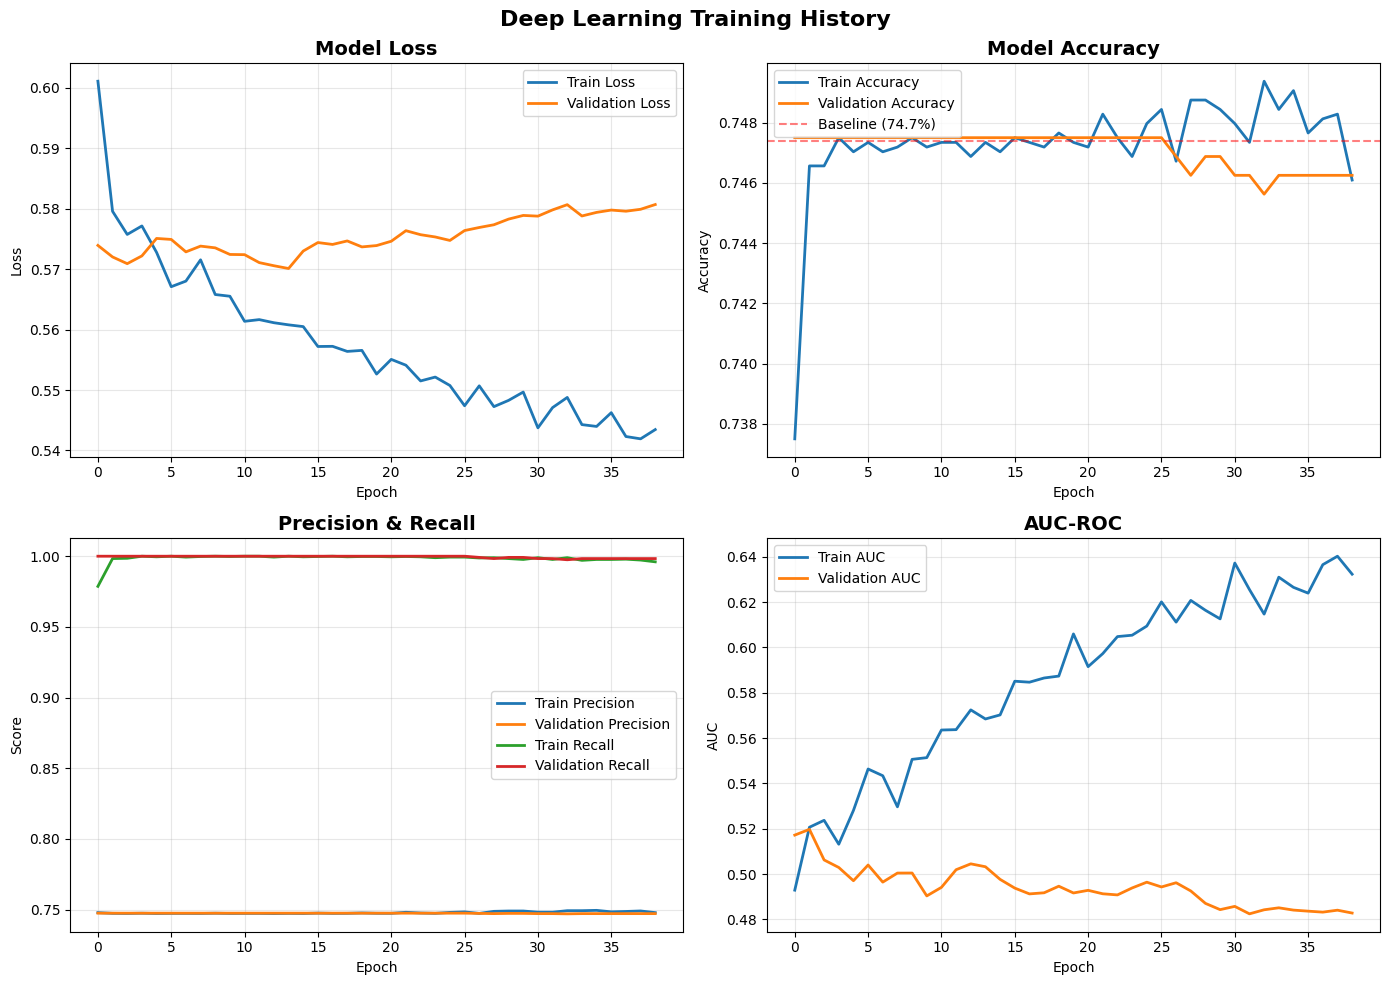

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Deep Learning Training History', fontsize=16, fontweight='bold')

axes[0, 0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
baseline = y.mean()
axes[0, 1].axhline(y=baseline, color='red', linestyle='--', alpha=0.5, label=f'Baseline ({baseline:.1%})')
axes[0, 1].legend()

axes[1, 0].plot(history.history['precision'], label='Train Precision', linewidth=2)
axes[1, 0].plot(history.history['val_precision'], label='Validation Precision', linewidth=2)
axes[1, 0].plot(history.history['recall'], label='Train Recall', linewidth=2)
axes[1, 0].plot(history.history['val_recall'], label='Validation Recall', linewidth=2)
axes[1, 0].set_title('Precision & Recall', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

if 'auc' in history.history:
    axes[1, 1].plot(history.history['auc'], label='Train AUC', linewidth=2)
    axes[1, 1].plot(history.history['val_auc'], label='Validation AUC', linewidth=2)
    axes[1, 1].set_title('AUC-ROC', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('AUC')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [15]:
weights = model.layers[0].get_weights()[0]
importance = np.abs(weights).mean(axis=1)

feat_imp = pd.DataFrame({
    'feature': features,
    'importance': importance
}).sort_values('importance', ascending=False)
print(feat_imp.head(10))

                  feature  importance
19        clickbait_score    0.102795
12     like_dislike_ratio    0.102182
25  has_links_description    0.101674
20                   year    0.101270
4        subscriber_count    0.101215
10        like_view_ratio    0.100359
21                  month    0.099955
18     description_length    0.099702
27      caption_available    0.099537
13     comment_like_ratio    0.099423
